In [2]:
# Load libs and objects
import muon as mu
import scanpy as sc
import anndata as ad
import pandas as pd
import os

PROJECT_ROOT = r"C:\Users\mniu\Documents\neuroblastoma-multiome"

adata_rna = sc.read_h5ad(os.path.join(PROJECT_ROOT, "data", "processed", "Be2c_rna_processed.h5ad"))
adata_atac = sc.read_h5ad(os.path.join(PROJECT_ROOT, "data", "processed", "Be2c_atac_processed.h5ad"))

print(f"RNA: {adata_rna.shape}")
print(f"ATAC: {adata_atac.shape}")

C:\envs\nb\lib\site-packages\muon\_core\preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


RNA: (16818, 2721)
ATAC: (11026, 216035)


In [6]:
# Find shared barcodes
rna_barcodes = set(adata_rna.obs_names)
atac_barcodes = set(adata_atac.obs_names)

shared = rna_barcodes & atac_barcodes
print(f"RNA cells: {len(rna_barcodes)}")
print(f"ATAC cells: {len(atac_barcodes)}")
print(f"Shared cells: {len(shared)}")
print(f"RNA-only: {len(rna_barcodes - atac_barcodes)}")
print(f"ATAC-only: {len(atac_barcodes - rna_barcodes)}")

RNA cells: 16818
ATAC cells: 11026
Shared cells: 11026
RNA-only: 5792
ATAC-only: 0


In [7]:
# Subset to shared barcodes
shared_list = sorted(list(shared))

adata_rna_paired = adata_rna[shared_list].copy()
adata_atac_paired = adata_atac[shared_list].copy()

print(f"RNA paired: {adata_rna_paired.shape}")
print(f"ATAC paired: {adata_atac_paired.shape}")
assert adata_rna_paired.n_obs == adata_atac_paired.n_obs
print("Barcode alignment confirmed")

RNA paired: (11026, 2721)
ATAC paired: (11026, 216035)
Barcode alignment confirmed


In [8]:
# Create MuData object
mdata = mu.MuData({"rna": adata_rna_paired,
                   "atac": adata_atac_paired})
print(mdata)

MuData object with n_obs × n_vars = 11026 × 218756
  2 modalities
    rna:	11026 × 2721
      obs:	'cell_line', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'n_genes', 'leiden'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'scrublet', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    atac:	11026 × 216035
      obs:	'n_peaks', 'total_counts', 'leiden'
      uns:	'leiden', 'leiden_colors', 'lsi', 'neighbors', 'umap'
      obsm:	'X_lsi', 'X_lsi_filtered', 'X_umap'
      varm:	'LSI'
      obsp:	'connectivities', 'distances'


C:\envs\nb\lib\site-packages\mudata\_core\mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
C:\envs\nb\lib\site-packages\mudata\_core\mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [9]:
# add shared metadata
mdata.obs['MYCN_status'] = 'amplified'
mdata.obs['cell_line'] = 'Be2c'
print(mdata.obs.head())

                   rna:cell_line  rna:n_genes_by_counts  rna:total_counts  \
AAACAGCCAAACTAAG-1          Be2c                   5509             14788   
AAACAGCCAATTGAGA-1          Be2c                   3139              6047   
AAACAGCCACAAAGCG-1          Be2c                   3482              6590   
AAACAGCCACCTACGG-1          Be2c                   3135              5739   
AAACATGCAGCGCTTG-1          Be2c                   4471             10078   

                    rna:total_counts_mt  rna:pct_counts_mt  rna:doublet_score  \
AAACAGCCAAACTAAG-1                  301           2.035434           0.104218   
AAACAGCCAATTGAGA-1                  558           9.227716           0.081748   
AAACAGCCACAAAGCG-1                  223           3.383915           0.113924   
AAACAGCCACCTACGG-1                   99           1.725039           0.086050   
AAACATGCAGCGCTTG-1                  172           1.706688           0.205721   

                    rna:predicted_doublet  rna:n_g

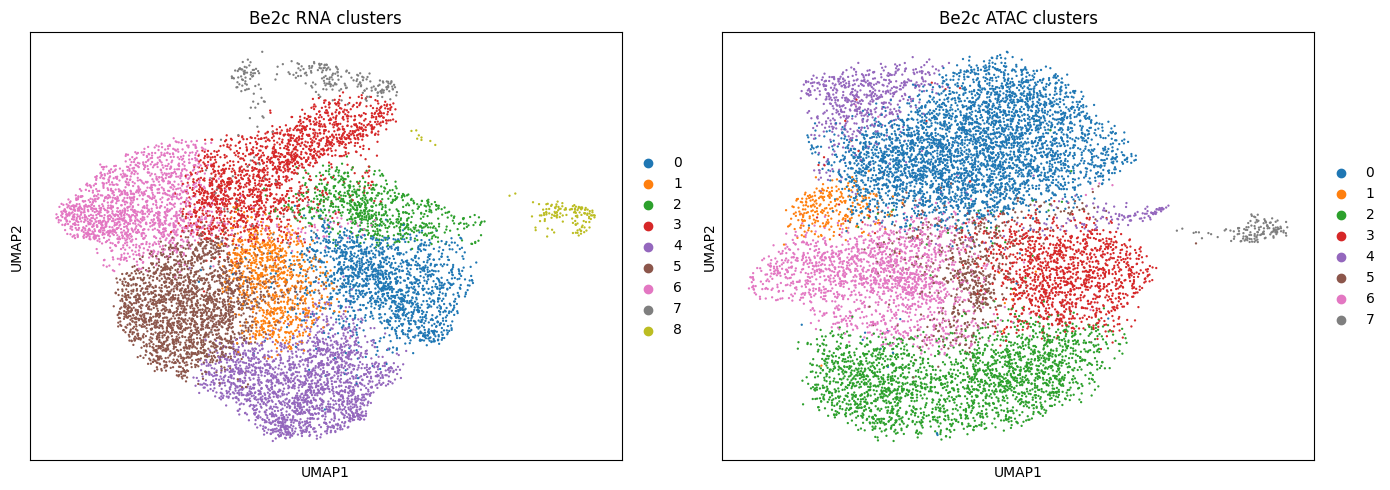

In [10]:
# Side by side UMAP
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

sc.pl.umap(mdata['rna'], color = 'leiden', title = 'Be2c RNA clusters', ax = axes[0], show = False)
sc.pl.umap(mdata['atac'], color = 'leiden', title = 'Be2c ATAC clusters', ax = axes[1], show = False)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "outputs", "figures", "Be2c_rna_atac_umap.png"), dpi = 150, bbox_inches = 'tight')
plt.show()

In [12]:
# concordance table
concordance = pd.crosstab(mdata['rna'].obs['leiden'], mdata['atac'].obs['leiden'],
                          rownames = ['RNA cluster'], colnames = ['ATAC cluster'])
print("Raw concordance")
print(concordance)

# Normalized by RNA cluster (what % of each RNA cluster falls in each ATAC cluster)
concordance_norm = concordance.div(concordance.sum(axis = 1), axis = 0).round(2)
print("\nNormalized by RNA cluster (row %):")
print(concordance_norm)

Raw concordance
ATAC cluster     0   1    2     3    4    5    6    7
RNA cluster                                          
0              106  21  163    73   17  342  831    1
1              250   7  515    38   18   16   10    0
2               71  23    1     2    4   67  548    0
3              969  68   16    40  481   63  125    1
4               74  63  632  1110   43   41   32    0
5             1047  36  943    36   17   15   45    0
6             1459  41   10    10    7   36   31    1
7               20   3   14    28  150   20   37    1
8                1   0    3     1    0    3    3  126

Normalized by RNA cluster (row %):
ATAC cluster     0     1     2     3     4     5     6     7
RNA cluster                                                 
0             0.07  0.01  0.10  0.05  0.01  0.22  0.53  0.00
1             0.29  0.01  0.60  0.04  0.02  0.02  0.01  0.00
2             0.10  0.03  0.00  0.00  0.01  0.09  0.77  0.00
3             0.55  0.04  0.01  0.02  0.27  0.04 

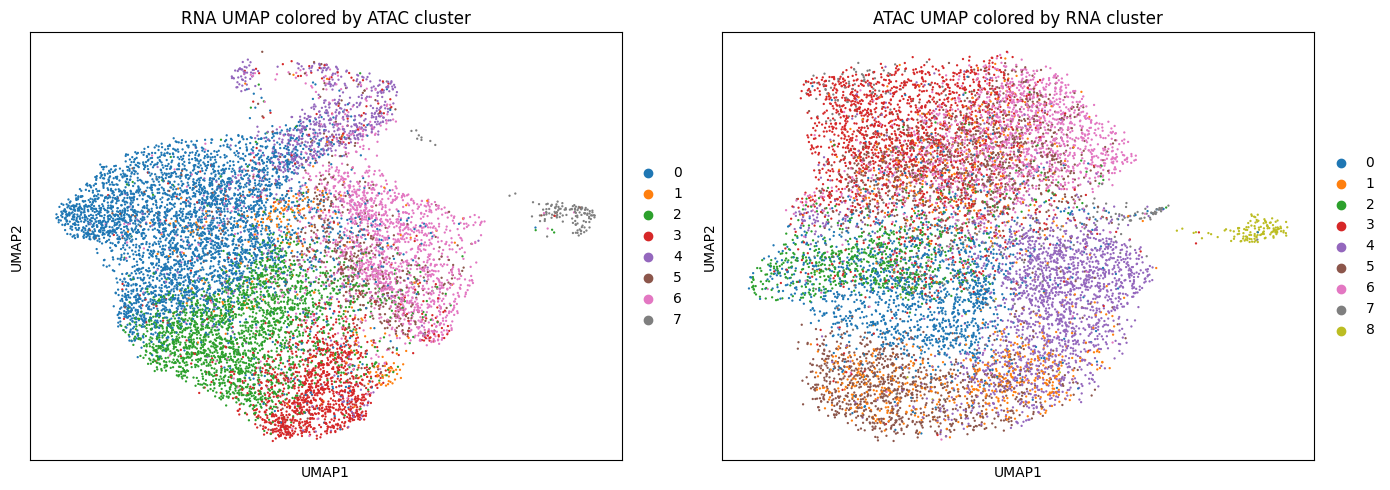

In [14]:
# Add ATAC cluster labels to RNA obs and vice versa
mdata['rna'].obs['atac_leiden'] = mdata['atac'].obs['leiden']
mdata['atac'].obs['rna_leiden'] = mdata['rna'].obs['leiden']

fig, axes = plt.subplots(1, 2, figsize = (14, 5))
sc.pl.umap(mdata['rna'], color = 'atac_leiden', title = 'RNA UMAP colored by ATAC cluster', ax = axes[0], show = False)
sc.pl.umap(mdata['atac'], color = 'rna_leiden', title = 'ATAC UMAP colored by RNA cluster', ax = axes[1], show = False)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "outputs", "figures", "Be2c_cross_modal_umap.png"), dpi = 150, bbox_inches = 'tight')
plt.show()

In [19]:
from scipy import sparse

# Convert ATAC .X back to sparse
mdata['atac'].X = sparse.csr_matrix(mdata['atac'].X)
print(f"ATAC .X type after conversion: {type(mdata['atac'].X)}")
print(f"ATAC .X size after conversion: {mdata['atac'].X.data.nbytes / (1024 * 1024):.1f} MB")
print(f"Sparsity: {1 - mdata['atac'].X.nnz / (mdata['atac'].X.shape[0] * mdata['atac'].X.shape[1]):.1%}")

ATAC .X type after conversion: <class 'scipy.sparse._csr.csr_matrix'>
ATAC .X size after conversion: 862.1 MB
Sparsity: 95.3%


In [27]:
print(f"dtype: {adata_atac_original.X.dtype}")
print(f"Sample non-zero values: {adata_atac_original.X.data[:20]}")

dtype: int64
Sample non-zero values: [1 1 2 1 1 1 2 1 1 1 1 1 1 1 2 1 2 1 1 1]


In [28]:
from scipy import sparse
import numpy as np

# Convert to int32 for smaller file size
mdata['atac'].X = sparse.csr_matrix(adata_atac_original_paired.X.astype(np.int32))
print(f"Size after int32: {mdata['atac'].X.data.nbytes / (1024 * 1024):.1f} MB")

# Save
out_path = os.path.join(PROJECT_ROOT, "data", "processed", "Be2c_mudata.h5mu")
mdata.write(out_path, compression = 'gzip')
print(f"File size: {os.path.getsize(out_path) / (1024 * 1024):.1f} MB")

Size after int32: 431.1 MB
File size: 411.6 MB


C:\envs\nb\lib\site-packages\mudata\_core\mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
C:\envs\nb\lib\site-packages\mudata\_core\mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [29]:
# Resave original ATAC h5ad with int32
adata_atac_int32 = adata_atac_original.copy()
adata_atac_int32.X = sparse.csr_matrix(adata_atac_original.X.astype(np.int32))
adata_atac_int32.write_h5ad(os.path.join(PROJECT_ROOT, "data", "raw", "GSM8159270_Be2c_atac.h5ad"), compression = 'gzip')
print("Raw ATAC file resaved as int32")

Raw ATAC file resaved as int32


## Week3 Day 4 - Paired Muon Object (Be2c)

### Barcode Alignment
- RNA cells: 16818
- ATAC cells: 11026
- Shared (paired) cells: 11026 (100% ATAC overlap with RNA)
- RNA-only cells: 5792 (normal for 10x Multiome - lower ATAC capture rate)

### MuData Structure
- mdata['rna']: 11026 x 2721 HVGs
- mdata['atac']: 11026 x 216035 peaks
- Shared obs: MYCN_status (amplified), cell_line (Be2c)
- ATAC .X stored as int32 sparse counts (raw accessibility counts, not TF-IDF transformed), TF-IDF/LSI results retained in .obsm['X_lsi']

### Concordance Analysis
Cross-tabulation of RNA vs ATAC Leiden cluster assignments showed strong dominant mapping for most clusters:
- RNA cluster 6 -> ATAC cluster 0 (91%)
- RNA cluster 8 -> ATAC cluster 7 (92%)
- RNA cluster 2 -> ATAC cluster 6 (77%)
Indicates meaningful concordance between modalities without any joint integration: similar cell groupings captured independently by both RNA expression and chromatic accessibility.

### Cross-Modal UMAP
Colors in RNA UMAP (bt ATAC cluster) and ATAC UMAP (by RNA cluster) both show clear spatial structure: cells neighboring in RNA space tend to share ATAC cluster assignments, and vice versa. Be2c's isolated cluster 8 (RNA) maps cleanly to isolated cluster 7 (ATAC), visible in both UMAPs independently, strong evidence this represents a real biological subpopulation.

### File
Saved as Be2c_mudata.h5mu (~400 MB after int32 and gzip compression)